# Notebook 7: Event Ideology Map

Builds the geographic data product behind the interactive ideology map
(*Atlas of Inequality* style) for the web frontend.

**Inputs**
- `../data/processed/events_{size}_{period}.pkl` — 8 cleaned, scored event tables (pre-LCC)
- `../raw-data/full_data_mod_pickle.csv` — raw events, for `place_latitude/longitude/place_name` only

**Outputs** to `../data/map/`
- `coords_lookup.pkl` — cached id → coordinates (one-time 13.6 GB scan) *(local only, gitignored)*
- `events.geojson` — per-event contract for local popup development *(local only, gitignored)*
- `events_aggregated.geojson` — location × year × size sufficient statistics, **published** (no per-event rows, no individual data)
- `color_params.json` — pinned color scheme parameters (shared with the frontend)
- `preview_small_all.png` — static verification render

**Pipeline**
1. Load + tag (size, year) the cleaned events
2. Re-join coordinates from the raw CSV (cached)
3. `location_id` (exact coords) + resolved `place_name`
4. Color parameters: `S_ref` + graying cap
5. Export the per-event GeoJSON contract (local)
6. Static verification preview
7. Aggregated export for public hosting


In [1]:
import json
import sys
import time
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path('../src').resolve()))
import event_map as em

PROC = Path('../data/processed')
RAW = Path('../raw-data/full_data_mod_pickle.csv')
MAP = Path('../data/map'); MAP.mkdir(exist_ok=True)

KEYS = [
    'small_2013-2014', 'small_2014-2015', 'small_2015-2016', 'small_2016-2017',
    'medium_2013-2014', 'medium_2014-2015', 'medium_2015-2016', 'medium_2016-2017',
]

## 1. Load cleaned events, tag size + year

In [2]:
frames = []
for k in KEYS:
    size, year = k.split('_', 1)
    df = pd.read_pickle(PROC / f'events_{k}.pkl').copy()
    df['size'], df['year'] = size, year
    frames.append(df)
events = pd.concat(frames, ignore_index=True)
print(f'events: {len(events):,} across {events.year.nunique()} years x {events["size"].nunique()} sizes')

events: 76,310 across 4 years x 2 sizes


## 2. Re-join coordinates from the raw CSV (cached)

Coordinates were dropped during cleaning, so we re-attach them from the raw file
by event `id`, reading only the four needed columns in chunks. The result is
cached to `coords_lookup.pkl`; delete that file to force a re-scan.

In [3]:
CACHE = MAP / 'coords_lookup.pkl'
if CACHE.exists():
    coords = pd.read_pickle(CACHE)
    print(f'loaded cached coords: {len(coords):,}')
else:
    proc_ids = set(events['id'])
    cols = ['id', 'place_latitude', 'place_longitude', 'place_name']
    keep, t0 = [], time.time()
    for chunk in pd.read_csv(RAW, usecols=cols, chunksize=100_000):
        hit = chunk[chunk['id'].isin(proc_ids)]
        if len(hit):
            keep.append(hit)
    coords = pd.concat(keep, ignore_index=True)
    coords = coords.dropna(subset=['place_latitude', 'place_longitude']).drop_duplicates('id')
    coords.to_pickle(CACHE)
    print(f'scanned raw + cached coords: {len(coords):,} in {time.time()-t0:.0f}s')

events = events.merge(coords, on='id', how='left')
assert events['place_latitude'].notna().all(), 'null coordinates after join'
print(f'coords joined, 0 nulls — {len(events):,} events')

loaded cached coords: 76,310
coords joined, 0 nulls — 76,310 events


## 3. Location identity + name resolution

Events at byte-identical `(latitude, longitude)` share a `location_id` (no
rounding). Each location takes the most-frequent non-empty `place_name`, else
`"unnamed location"`.

In [4]:
events['location_id'] = events.groupby(['place_latitude', 'place_longitude']).ngroup()

def resolve_name(names):
    s = names.dropna()
    s = s[s.astype(str).str.strip() != '']
    return s.mode().iloc[0] if not s.empty else 'unnamed location'

loc_name = events.groupby('location_id')['place_name'].apply(resolve_name)
events['place_name_resolved'] = events['location_id'].map(loc_name)
print(f'locations: {events.location_id.nunique():,} | '
      f'unnamed: {(loc_name == "unnamed location").sum():,}')

locations: 7,274 | unnamed: 0


## 4. Color parameters (`S_ref`, graying cap)

The scheme (see `../src/event_map.py`): diverging blue–white–red on the
attendee-weighted mean lean, blended toward gray by the attendee-weighted std.
`S_ref` is the 95th percentile of per-location weighted std (locations with ≥2
events) — the std that maps to full gray. Saved to `color_params.json` so the
frontend renders identically.

In [5]:
def loc_std(g):
    _, s = em.weighted_mean_std(g['average_normalized_min_max'], g['n_political_attending'])
    return s

multi = events.groupby('location_id').filter(lambda g: len(g) >= 2)
stds = multi.groupby('location_id', group_keys=False).apply(loc_std, include_groups=False)
S_REF = float(np.percentile(stds, 95)) if len(stds) else 1.0
print(f'multi-event locations: {len(stds):,} | S_ref (p95 std) = {S_REF:.4f}')

(MAP / 'color_params.json').write_text(json.dumps(em.color_params(S_REF), indent=2))
print('wrote color_params.json')

multi-event locations: 4,318 | S_ref (p95 std) = 0.4574
wrote color_params.json


## 5. Export the per-event GeoJSON contract

One Point feature per event (geometry `[lon, lat]`), carrying the fields the
frontend filters, aggregates, colors, and (later) pops up on.

In [6]:
feats = []
for r in events.itertuples(index=False):
    feats.append({
        'type': 'Feature',
        'geometry': {'type': 'Point',
                     'coordinates': [round(r.place_longitude, 6), round(r.place_latitude, 6)]},
        'properties': {
            'location_id': int(r.location_id),
            'place_name': r.place_name_resolved,
            'year': r.year,
            'size': r.size,
            'average_normalized': round(float(r.average_normalized_min_max), 4),
            'percent_political': round(float(r.percent_political), 4),
            'n_political': int(r.n_political_attending),
            'n_attending': int(r.n_attending),
            'date': str(r.date),
        },
    })
fc = {'type': 'FeatureCollection', 'features': feats}
(MAP / 'events.geojson').write_text(json.dumps(fc, separators=(',', ':')))
print(f'wrote events.geojson: {len(feats):,} features, '
      f'{(MAP / "events.geojson").stat().st_size / 1e6:.1f} MB')

wrote events.geojson: 76,310 features, 22.1 MB


## 6. Static verification preview

Aggregate one filter state (all years, small) with the same client-side logic
the frontend uses, render with the shared color scheme, and sanity-check the
four color corners. Predominantly blue is expected (left-leaning Copenhagen).

filter=small/ALL: 6,151 locations
  left consensus   -> (60, 106, 222)
  right consensus  -> (218, 65, 60)
  calm center      -> (245, 245, 245)
  battleground     -> (164, 164, 164)


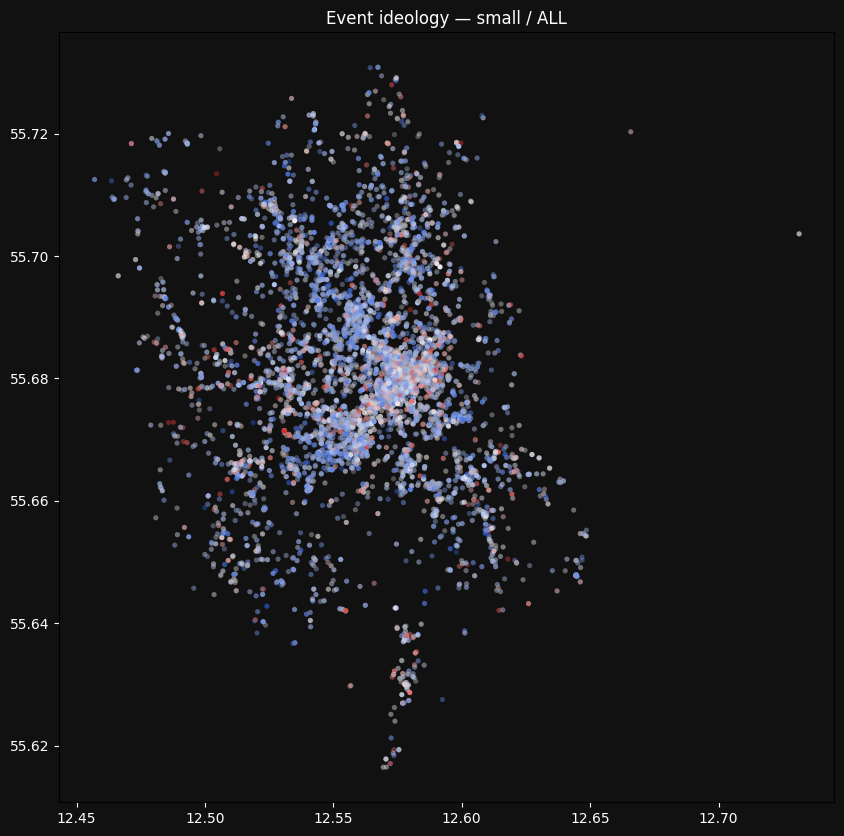

In [7]:
YEAR, SIZE = 'ALL', 'small'
groups = defaultdict(list)
for f in fc['features']:
    p = f['properties']
    if (SIZE == 'ALL' or p['size'] == SIZE) and (YEAR == 'ALL' or p['year'] == YEAR):
        groups[p['location_id']].append((f['geometry']['coordinates'], p))

xs, ys, cols, alphas = [], [], [], []
for items in groups.values():
    vals = [p['average_normalized'] for _, p in items]
    wts = [p['n_political'] for _, p in items]
    mean, std = em.weighted_mean_std(vals, wts)
    pct = sum(p['percent_political'] * p['n_political'] for _, p in items) / sum(wts)
    lon, lat = items[0][0]
    r, g, b = em.bivariate_color(mean, std, S_REF)
    xs.append(lon); ys.append(lat)
    cols.append((r/255, g/255, b/255)); alphas.append(0.35 + 0.65 * pct)

print(f'filter={SIZE}/{YEAR}: {len(xs):,} locations')
for label, m, s in [('left consensus', -0.9, 0.0), ('right consensus', 0.9, 0.0),
                     ('calm center', 0.0, 0.0), ('battleground', 0.0, S_REF)]:
    print(f'  {label:16} -> {em.bivariate_color(m, s, S_REF)}')

fig, ax = plt.subplots(figsize=(10, 10), facecolor='#111')
ax.set_facecolor('#111')
ax.scatter(xs, ys, c=cols, alpha=alphas, s=14, edgecolors='none')
ax.set_title(f'Event ideology — {SIZE} / {YEAR}', color='w')
ax.tick_params(colors='w')
fig.savefig(MAP / 'preview_small_all.png', dpi=110, bbox_inches='tight', facecolor='#111')
plt.show()

## 7. Aggregated export for public hosting

The per-event `events.geojson` above stays **local (gitignored)** for popup
development. For public hosting we publish only **sufficient statistics per
`(location × year × size)`** — no per-event rows, no dates, nothing that
exposes the underlying event dataset or any individual.

Each cell carries `n_events`, `w_sum` (Σ `n_political`), `wx_sum` (Σ w·score),
`wxx_sum` (Σ w·score²), `wp_sum` (Σ w·percent_political), `n_att_sum`. The
frontend sums these across the active year/size selection per location and
recovers the attendee-weighted statistics exactly:

`mean = wx_sum / w_sum` &nbsp;·&nbsp; `std = √(wxx_sum / w_sum − mean²)`


In [8]:
# Group per (location_id, year, size) into sufficient statistics.
cells = {}
for r in events.itertuples(index=False):
    key = (int(r.location_id), r.year, r.size)
    c = cells.get(key)
    if c is None:
        c = cells[key] = {'lon': round(r.place_longitude, 6), 'lat': round(r.place_latitude, 6),
                          'name': r.place_name_resolved,
                          'n': 0, 'w': 0.0, 'wx': 0.0, 'wxx': 0.0, 'wp': 0.0, 'natt': 0}
    w = float(r.n_political_attending); x = float(r.average_normalized_min_max)
    c['n'] += 1; c['w'] += w; c['wx'] += w * x; c['wxx'] += w * x * x
    c['wp'] += float(r.percent_political) * w; c['natt'] += int(r.n_attending)

agg_feats = [{
    'type': 'Feature',
    'geometry': {'type': 'Point', 'coordinates': [c['lon'], c['lat']]},
    'properties': {
        'location_id': lid, 'place_name': c['name'], 'year': yr, 'size': sz,
        'n_events': c['n'], 'w_sum': int(c['w']),
        'wx_sum': round(c['wx'], 6), 'wxx_sum': round(c['wxx'], 6),
        'wp_sum': round(c['wp'], 6), 'n_att_sum': c['natt'],
    },
} for (lid, yr, sz), c in cells.items()]

agg = {'type': 'FeatureCollection', 'features': agg_feats}
(MAP / 'events_aggregated.geojson').write_text(json.dumps(agg, separators=(',', ':')))
print(f'wrote events_aggregated.geojson: {len(agg_feats):,} cells, '
      f'{(MAP / "events_aggregated.geojson").stat().st_size / 1e6:.1f} MB')

# Sanity: reconstruct small/ALL from cells and compare to the per-event preview.
loc = defaultdict(lambda: {'w': 0.0, 'wx': 0.0, 'wxx': 0.0})
for (lid, yr, sz), c in cells.items():
    if sz != 'small':
        continue
    d = loc[lid]; d['w'] += c['w']; d['wx'] += c['wx']; d['wxx'] += c['wxx']
means = {lid: d['wx'] / d['w'] for lid, d in loc.items()}
print(f'reconstructed small/ALL locations: {len(means):,} (per-event preview: {len(xs):,})')


wrote events_aggregated.geojson: 17,830 cells, 4.9 MB
reconstructed small/ALL locations: 6,151 (per-event preview: 6,151)
